# Fake News Detection




## Objective


The objective of this assignment is to develop a Semantic Classification model. You will be using Word2Vec method to extract the semantic relations from the text and develop a basic understanding of how to train supervised models to categorise text based on its meaning, rather than just syntax. You will explore how this technique is used in situations where understanding textual meaning plays a critical role in making accurate and efficient decisions.


## Business Objective

The spread of fake news has become a significant challenge in today’s digital world. With the massive volume of news articles published daily, it’s becoming harder to distinguish between credible and misleading information. This creates a need for systems that can automatically classify news articles as true or fake, helping to reduce misinformation and protect public trust.


In this assignment, you will develop a Semantic Classification model that uses the Word2Vec method to detect recurring patterns and themes in news articles. Using supervised learning models, the goal is to build a system that classifies news articles as either fake or true.


<h2> Pipelines that needs to be performed </h2>

You need to perform the following tasks to complete the assignment:

<ol type="1">

  <li> Data Preparation
  <li> Text Preprocessing
  <li> Train Validation Split
  <li> EDA on Training Data
  <li> EDA on Validation Data [Optional]
  <li> Feature Extraction
  <li> Model Training and Evaluation

</ol>

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Dictionary


For this assignment, you will work with two datasets, `True.csv` and `Fake.csv`.
Both datasets contain three columns:
<ul>
  <li> title of the news article
  <li> text of the news article
  <li> date of article publication
</ul>

`True.csv` dataset includes 21,417 true news, while the `Fake.csv` dataset comprises 23,502 fake news.

## Installing required Libraries

In [1]:
!pip install --upgrade numpy==1.26.4
!pip install --upgrade pandas==2.2.2
!pip install --upgrade nltk==3.9.1
!pip install --upgrade spacy==3.7.5
!pip install --upgrade scipy==1.12
!pip install --upgrade pydantic==2.10.5
!pip install wordcloud==1.9.4
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Obtaining dependency information for pydantic==2.10.5 from https://files.pythonhosted.org/packages/58/26/82663c79010b28eddf29dcdd0ea723439535fa917fce5905885c0e9ba562/pydantic-2.10.5-py3-none-any.whl.metadata
  Using cached pydantic-2.10.5-py3-none-any.whl.metadata (30 kB)
  Obtaining dependency information for pydantic-core==2.27.2 from https://files.pythonhosted.org/packages/1f/ea/cd7209a889163b8dcca139fe32b9687dd05249161a3edda62860430457a5/pydantic_core-2.27.2-cp312-cp312-win_amd64.whl.metadata
  Using cached pydantic_core-2.27.2-cp312-cp312-win_amd64.whl.metadata (6.7 kB)
Using cached pydantic-2.10.5-py3-none-any.whl (431 kB)
Using cached pydantic_core-2.27.2-cp312-cp312-win_amd64.whl (2.0 MB)
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.5
    Uninstalling pydantic_core-2.41.5:
      Successfully uninstalled pydantic_core-2.41.5
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.5
    Uninstalling pydantic-2


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 325.1 kB/s eta 0:00:40
     --------------------------------------- 0.0/12.8 MB 326.8 kB/s eta 0:00:40
      --------------------------------------- 0.3/12.8 MB 1.8 MB/s eta 0:00:08
     ----- ---------------------------------- 1.6/12.8 MB 7.4 MB/s eta 0:00:02
     -------- ------------------------------- 2.7/12.8 MB 10.2 MB/s eta 0:00:01
     ---------- ----------------------------- 3.5/12.8 MB 11.1 MB/s eta 0:00:01
     ------------------- -------------------- 6.2/12.8 MB 17.3 MB/s eta 0:00:01
     ---------------------- ----------------- 7.2/12.8 MB 17.7 MB/s eta 0:00:01
     --------------------------- ------------ 8.9/12.8 MB 19.6 MB/s eta 0:00:01
     ------------------------------- ------- 10.2/12.8 MB 20.4 MB/s eta 0:00:01
     ------------------------------- ------- 10.5/12.8 MB 


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importing the necessary libraries

In [2]:
# Import essential libraries for data manipulation and analysis
import numpy as np  # For numerical operations and arrays
import pandas as pd  # For working with dataframes and structured data
import re  # For regular expression operations (text processing)
import nltk  # Natural Language Toolkit for text processing
import spacy  # For advanced NLP tasks
import string  # For handling string-related operations

# Optional: Uncomment the line below to enable GPU support for spaCy (if you have a compatible GPU)
#spacy.require_gpu()

# Load the spaCy small English language model
nlp = spacy.load("en_core_web_sm")

# For data visualization
import seaborn as sns  # Data visualization library for statistical graphics
import matplotlib.pyplot as plt  # Matplotlib for creating static plots
# Configure Matplotlib to display plots inline in Jupyter Notebook
%matplotlib inline

# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# For interactive plots
from plotly.offline import plot  # Enables offline plotting with Plotly
import plotly.graph_objects as go  # For creating customizable Plotly plots
import plotly.express as px  # A high-level interface for Plotly

# For preprocessing and feature extraction in machine learning
from sklearn.feature_extraction.text import (  # Methods for text vectorization
    CountVectorizer,  # Converts text into a bag-of-words model
)

# Import accuracy, precision, recall, f_score from sklearn to predict train accuracy
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Pretty printing for better readability of output
from pprint import pprint

# For progress tracking in loops (useful for larger datasets)
from tqdm import tqdm, tqdm_notebook  # Progress bar for loops
tqdm.pandas()  # Enables progress bars for pandas operations


In [ ]:
## Change the display properties of pandas to max
# pd.set_option('display.max_colwidth', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)

## Load the data

Load the True.csv and Fake.csv files as DataFrames

In [3]:
# Import the first file - True.csv
# reading the true news data using pandas
true_df = pd.read_csv("True.csv")

# Import the second file - Fake.csv
# reading the fake news data
fake_df = pd.read_csv("Fake.csv")

# print out a simple check to see if data is loaded correctly
print("Data loaded ok!")
print("Number of true news:", true_df.shape[0])
print("Number of fake news:", fake_df.shape[0])


Data loaded ok!
Number of true news: 21417
Number of fake news: 23523


## **1.** Data Preparation  <font color = red>[10 marks]</font>





### **1.0** Data Understanding

In [4]:
# Inspect the DataFrame with True News to understand the given data
true_df.head()

,title,text,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,"December 29, 2017"


In [5]:
# Inspect the DataFrame with Fake News to understand the given data
fake_df.head()

,title,text,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...","December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...","December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,"December 25, 2017"


In [6]:
# Print the column details for True News DataFrame
print("Info about True news data:")
true_df.info()

Info about True news data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   21417 non-null  object
 1   text    21417 non-null  object
 2   date    21417 non-null  object
dtypes: object(3)
memory usage: 502.1+ KB


In [7]:
# Print the column details for Fake News Dataframe
print("Info about Fake news data:")
fake_df.info()

Info about Fake news data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23523 entries, 0 to 23522
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   23502 non-null  object
 1   text    23502 non-null  object
 2   date    23481 non-null  object
dtypes: object(3)
memory usage: 551.4+ KB


In [8]:
# Print the column names of both DataFrames
print("Columns in True news:", true_df.columns.tolist())
print("Columns in Fake news:", fake_df.columns.tolist())

Columns in True news: ['title', 'text', 'date']
Columns in Fake news: ['title', 'text', 'date']


### **1.1** Add new column  <font color = red>[3 marks]</font> <br>

Add new column `news_label` to both the DataFrames and assign labels

In [9]:
# Add a new column 'news_label' to the true news DataFrame and assign the label "1" to indicate that these news are true
true_df['news_label'] = 1
# Add a new column 'news_label' to the fake news DataFrame and assign the label "0" to indicate that these news are fake
fake_df['news_label'] = 0
# let's just make sure the labels got added correctly
print("Labels in true data:", true_df['news_label'].unique())
print("Labels in fake data:", fake_df['news_label'].unique())

Labels in true data: [1]
Labels in fake data: [0]


### **1.2** Merge DataFrames  <font color = red>[2 marks]</font> <br>

Create a new Dataframe by merging True and Fake DataFrames

In [10]:
# Combine the true and fake news DataFrames into a single DataFrame
# we use concat to stack them on top of each other
# resetting index so we don't end up with messy row numbers
df = pd.concat([true_df, fake_df], axis=0).reset_index(drop=True)
print("Combined dimensions:", df.shape)

Combined dimensions: (44940, 4)


In [11]:
# Display the first 5 rows of the combined DataFrame to verify the result
df.head()

,title,text,date,news_label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,"December 29, 2017",1


### **1.3** Handle the null values  <font color = red>[2 marks]</font> <br>

Check for null values and handle it by imputation or dropping the null values

In [12]:
# Check Presence of Null Values
print("Null values count in each column:")
print(df.isnull().sum())

Null values count in each column:
title         21
text          21
date          42
news_label     0
dtype: int64


In [13]:
# Handle Rows with Null Values
df.dropna(inplace=True)
print("Shape after handling nulls:", df.shape)

Shape after handling nulls: (44898, 4)


### **1.4** Merge the relevant columns and drop the rest from the DataFrame  <font color = red>[3 marks]</font> <br>

Combine the relevant columns into a new column `news_text` and then drop irrelevant columns from the DataFrame

In [15]:
# Combine the relevant columns into a new column 'news_text' by joining their values with a space
# both title and text are important for finding fake news, so we join them together
df['news_text'] = df['title'] + " " + df['text']
# Drop the irrelevant columns from the DataFrame as they are no longer needed
# we don't need these separate columns anymore
df.drop(columns=['title', 'text', 'date'], inplace=True)
# Display the first 5 rows of the updated DataFrame to check the result
df.head()

,news_label,news_text
0,1,"As U.S. budget fight looms, Republicans flip t..."
1,1,U.S. military to accept transgender recruits o...
2,1,Senior U.S. Republican senator: 'Let Mr. Muell...
3,1,FBI Russia probe helped by Australian diplomat...
4,1,Trump wants Postal Service to charge 'much mor...


## **2.** Text Preprocessing <font color = red>[15 marks]</font> <br>






On all the news text, you need to:
<ol type=1>
  <li> Make the text lowercase
  <li> Remove text in square brackets
  <li> Remove punctuation
  <li> Remove words containing numbers
</ol>


Once you have done these cleaning operations you need to perform POS tagging and lemmatization on the cleaned news text, and remove all words that are not tagged as NN or NNS.

### **2.1** Text Cleaning  <font color = red>[5 marks]</font> <br>



#### 2.1.0 Create a new DataFrame to store the processed data



In [16]:
# Create a DataFrame('df_clean') that will have only the cleaned news text and the lemmatized news text with POS tags removed

df_clean = pd.DataFrame()
# Add 'news_label' column to the new dataframe for topic identification
df_clean['news_label'] = df['news_label'].values
print("Created df_clean with shape:", df_clean.shape)


Created df_clean with shape: (44898, 1)


#### 2.1.1 Write the function to clean the text and remove all the unnecessary elements  <font color = red>[4 marks]</font> <br>



In [17]:
# Write the function here to clean the text and remove all the unnecessary elements
def clean_text(text):
    # Convert to lower case
    text = text.lower()
    
    # Remove text in square brackets (often these are video links or image tags)
    text = re.sub(r'\[.*?\]', '', text)
    
    # Remove punctuation
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    
    # Remove words with numbers
    text = re.sub(r'\w*\d\w*', '', text)
    
    # remove extra spaces just in case
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# quick test to see if it works
sample = "This is a TEST [remove this] with numbers like abc123 and punctuation!!!"
print("Before:", sample)
print("After:", clean_text(sample))


Before: This is a TEST [remove this] with numbers like abc123 and punctuation!!!
After: this is a test with numbers like and punctuation


#### 2.1.2  Apply the function to clean the news text and store the cleaned text in a new column within the new DataFrame. <font color = red>[1 mark]</font> <br>


In [18]:
# Apply the function to clean the news text and remove all unnecessary elements
# Store it in a separate column in the new DataFrame
# using progress_apply so we can see the progress bar
df_clean['cleaned_news'] = df['news_text'].progress_apply(clean_text)

print("\nText cleaning is done!")
df_clean.head()


100%|██████████| 44898/44898 [00:32<00:00, 1386.67it/s]


Text cleaning is done!


,news_label,cleaned_news
0,1,as us budget fight looms republicans flip thei...
1,1,us military to accept transgender recruits on ...
2,1,senior us republican senator let mr mueller do...
3,1,fbi russia probe helped by australian diplomat...
4,1,trump wants postal service to charge much more...


### **2.2** POS Tagging and Lemmatization  <font color = red>[10 marks]</font> <br>



#### 2.2.1 Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags <font color = red>[8 marks]</font> <br>



In [21]:
# Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags
# Write the function for POS tagging and lemmatization, filtering stopwords and keeping only NN and NNS tags
# Need to download stopwords first
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def pos_tag_and_lemmatize(text):
    # using spacy to process the text

    if pd.isna(text) or text == "":
        return ""
    
    # making sure it's a string before passing to spacy
    doc = nlp(str(text))
    
    lemmatized_words = []
    for token in doc:
        # check if it's a noun (NN for singular, NNS for plural) and not a stopword
        if token.text not in stop_words and token.tag_ in ['NN', 'NNS']:
            # saving the root form (lemma) of the word
            lemmatized_words.append(token.lemma_)
            
    # space separated string
    return ' '.join(lemmatized_words)

# simple test
test_txt = "the dogs are running in the parks and playing with ball"
print("Before:", test_txt)
print("After:", pos_tag_and_lemmatize(test_txt))


Before: the dogs are running in the parks and playing with ball
After: dog park ball


#### 2.2.2  Apply the POS tagging and lemmatization function to cleaned text and store it in a new column within the new DataFrame. <font color = red>[2 mark]</font> <br>

**NOTE: Store the cleaned text and the lemmatized text with POS tags removed in separate columns within the new DataFrame.**

**This will be useful for analysing character length differences between cleaned text and lemmatized text with POS tags removed during EDA.**


In [22]:
# Apply POS tagging and lemmatization function to cleaned text
# Store it in a separate column in the new DataFrame
# This step might take 10-15 minutes because spacy processes a lot of text!
df_clean['lemmatized_news'] = df_clean['cleaned_news'].progress_apply(pos_tag_and_lemmatize)

print("\nLemmatization is done!")
df_clean.head()


100%|██████████| 44898/44898 [49:17<00:00, 15.18it/s]  


Lemmatization is done!


,news_label,cleaned_news,lemmatized_news
0,1,as us budget fight looms republicans flip thei...,budget fight script head faction month expansi...
1,1,us military to accept transgender recruits on ...,military transgender recruit people time milit...
2,1,senior us republican senator let mr mueller do...,mueller job counsel investigation link electio...
3,1,fbi russia probe helped by australian diplomat...,probe diplomat trump campaign adviser diplomat...
4,1,trump wants postal service to charge much more...,trump service service ship package amzno fight...


### Save the Cleaned data as a csv file (Recommended)

In [23]:
## Recommended to perform the below steps to save time while rerunning the code
df_clean.to_csv("clean_df.csv", index=False)
df_clean = pd.read_csv("clean_df.csv")
print("Saved cleaned data to clean_df.csv")


Saved cleaned data to clean_df.csv


In [24]:
# Check the first few rows of the DataFrame
df_clean.head()

,news_label,cleaned_news,lemmatized_news
0,1,as us budget fight looms republicans flip thei...,budget fight script head faction month expansi...
1,1,us military to accept transgender recruits on ...,military transgender recruit people time milit...
2,1,senior us republican senator let mr mueller do...,mueller job counsel investigation link electio...
3,1,fbi russia probe helped by australian diplomat...,probe diplomat trump campaign adviser diplomat...
4,1,trump wants postal service to charge much more...,trump service service ship package amzno fight...


In [25]:
# Check the dimensions of the DataFrame
print("Cleaned dataframe shape:", df_clean.shape)

Cleaned dataframe shape: (44898, 3)


In [26]:
# Check the number of non-null entries and data types of each column
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   news_label       44898 non-null  int64 
 1   cleaned_news     44847 non-null  object
 2   lemmatized_news  44840 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.0+ MB


## **3.** Train Validation Split <font color = red>[5 marks]</font> <br>

In [27]:
# Import Train Test Split and split the DataFrame into 70% train and 30% validation data
from sklearn.model_selection import train_test_split
# using 70-30 split as asked in instructions
# we use random_state=42 so we get the same split every time we run this
# stratify makes sure the ratio of fake/true news is balanced in both train and validation sets
train_df, val_df = train_test_split(df_clean, test_size=0.3, random_state=42, stratify=df_clean['news_label'])
print("Training data shape:", train_df.shape)
print("Validation data shape:", val_df.shape)

Training data shape: (31428, 3)
Validation data shape: (13470, 3)


## **4.** Exploratory Data Analysis on Training Data  <font color = red>[40 marks]</font> <br>

Perform EDA on cleaned and preprocessed texts to get familiar with the training data by performing the tasks given below:

<ul>
  <li> Visualise the training data according to the character length of cleaned news text and lemmatized news text with POS tags removed
  <li> Using a word cloud, find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **4.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed  <font color = red>[10 marks]</font> <br>



##### 4.1.1  Add new columns to calculate the character lengths of the processed data columns  <font color = red>[3 marks]</font> <br>



In [28]:
# Add a new column to calculate the character length of cleaned news text
train_df['cleaned_news_len'] = train_df['cleaned_news'].apply(lambda x: len(str(x)))
# Add a new column to calculate the character length of lemmatized news text with POS tags removed
train_df['lemmatized_news_len'] = train_df['lemmatized_news'].apply(lambda x: len(str(x)))
print("Columns added successfully!")
# quick look at the average lengths
print("Average cleaned length:", train_df['cleaned_news_len'].mean())
print("Average lemmatized length:", train_df['lemmatized_news_len'].mean())

Columns added successfully!
Average cleaned length: 2423.9900407280134
Average lemmatized length: 715.3008781977854


##### 4.1.2  Create Histogram to visualise character lengths  <font color = red>[7 marks]</font> <br>

 Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

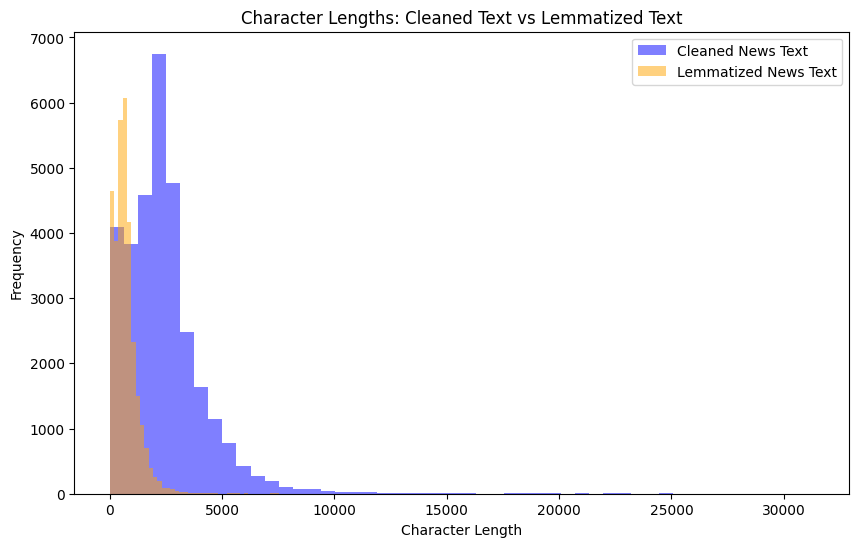

In [29]:
# Create a histogram plot to visualise character lengths
plt.figure(figsize=(10, 6))

# Add histogram for cleaned news text
plt.hist(train_df['cleaned_news_len'], bins=50, alpha=0.5, label='Cleaned News Text', color='blue')

# Add histogram for lemmatized news text with POS tags removed
plt.hist(train_df['lemmatized_news_len'], bins=50, alpha=0.5, label='Lemmatized News Text', color='orange')

# adding labels simply
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.title('Character Lengths: Cleaned Text vs Lemmatized Text')
plt.legend()
plt.show()

# The lemmatized text histogram is shifted to the left and is much narrower.
# This makes total sense because we threw away all non-noun words and stopwords, making the text much shorter.


### **4.2** Find and display the top 40 words by frequency among true and fake news in Training data after processing the text  <font color = red>[10 marks]</font> <br>



##### 4.2.1 Find and display the top 40 words by frequency among true news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

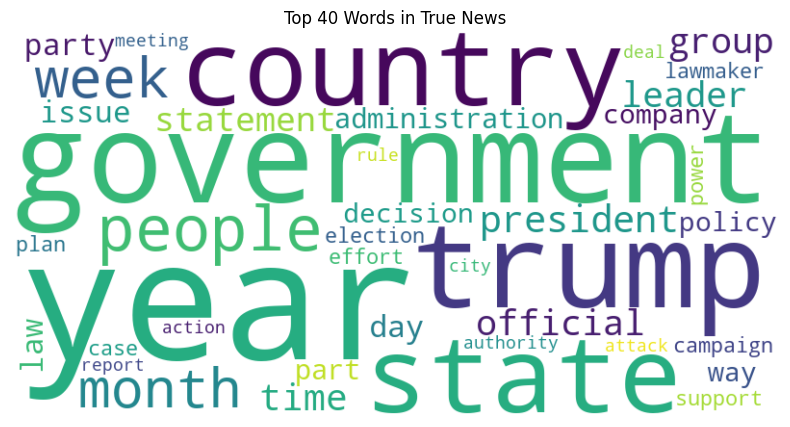

In [30]:
## Use a word cloud find the top 40 words by frequency among true news in the training data after processing the text
from wordcloud import WordCloud

# Filter news with label 1 (True News) and convert to it string and handle any non-string values
# joining all the true news lemmatized text into one giant string
true_text_blob = ' '.join(train_df[train_df['news_label'] == 1]['lemmatized_news'].astype(str).tolist())

# Generate word cloud for True News
# limiting to 40 words as per instructions
wordcloud_true = WordCloud(max_words=40, width=800, height=400, background_color='white').generate(true_text_blob)

# plotting it
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_true, interpolation='bilinear')
plt.axis('off')
plt.title('Top 40 Words in True News')
plt.show()


##### 4.2.2 Find and display the top 40 words by frequency among fake news in Training data after processing the text  <font color = red>[5 marks]</font> <br>

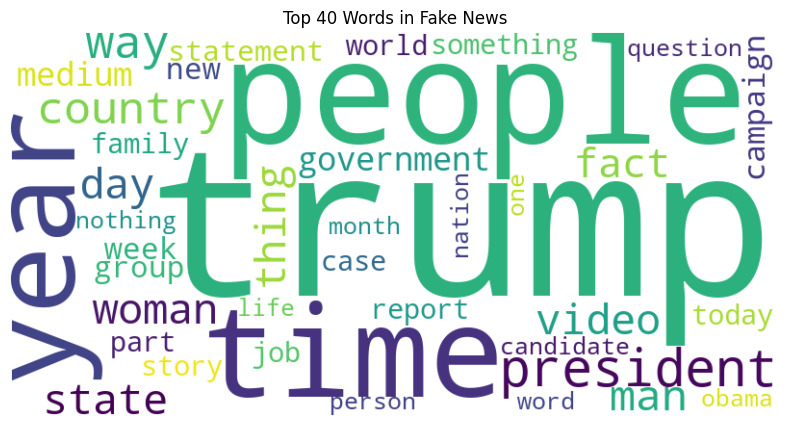

In [31]:
## Use a word cloud find the top 40 words by frequency among fake news in the training data after processing the text

# Filter news with label 0 (Fake News) and convert to it string and handle any non-string values
# joining all the fake news lemmatized text into one big string
fake_text_blob = ' '.join(train_df[train_df['news_label'] == 0]['lemmatized_news'].astype(str).tolist())

# Generate word cloud for Fake News
wordcloud_fake = WordCloud(max_words=40, width=800, height=400, background_color='white').generate(fake_text_blob)

# plotting it
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.axis('off')
plt.title('Top 40 Words in Fake News')
plt.show()


### **4.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  <font color = red>[20 marks]</font> <br>




##### 4.3.1 Write a function to get the specified top n-grams  <font color = red>[4 marks]</font> <br>



In [32]:
# Write a function to get the specified top n-grams
def get_top_ngrams(text_series, n=1, top_k=10):
    # using CountVectorizer to find the most common word combinations
    # n=1 means single words, n=2 means two words together (bigrams) etc.
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(text_series)
    bag_of_words = vec.transform(text_series)
    
    # sum up the counts for each n-gram across all text
    sum_words = bag_of_words.sum(axis=0) 
    
    # put the words and their counts into a list
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    
    # sort the list from highest count to lowest
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    
    # return only the top K requested
    return words_freq[:top_k]

print("get_top_ngrams function created!")


get_top_ngrams function created!


##### 4.3.2 Handle the NaN values  <font color = red>[1 mark]</font> <br>



In [33]:
# Handle NaN values in the text data
# filling any weird NaN values with empty strings so CountVectorizer doesn't give us an error
train_df['lemmatized_news'] = train_df['lemmatized_news'].fillna('')

print("NaN values handled.")


NaN values handled.


### For True News




##### 4.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

Top 10 Unigrams in True News:
trump: 24928
state: 14303
government: 13819
year: 13188
people: 10877
election: 9873
country: 9832
official: 9302
party: 8053
campaign: 7932


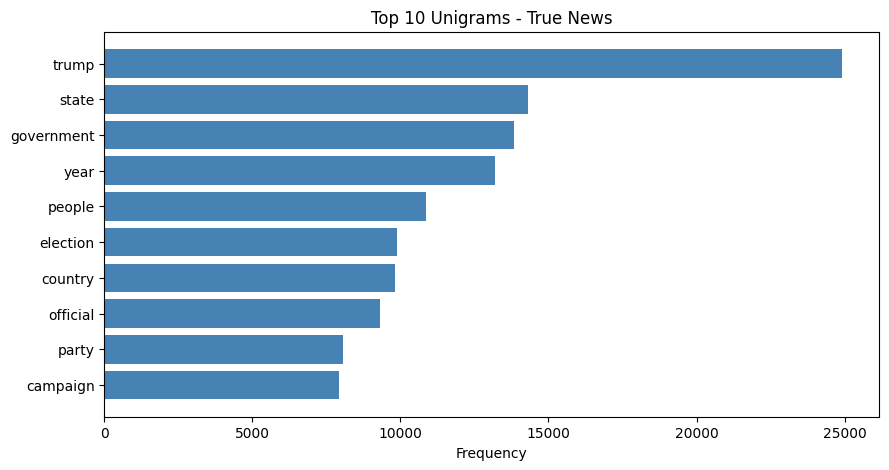

In [34]:
# Print the top 10 unigrams by frequency in true news and plot the same using a bar graph
true_news_text = train_df[train_df['news_label'] == 1]['lemmatized_news']
top_uni_true = get_top_ngrams(true_news_text, n=1, top_k=10)

print("Top 10 Unigrams in True News:")
for word, freq in top_uni_true:
    print(f"{word}: {freq}")

# plotting the bar graph
words = [w[0] for w in top_uni_true]
counts = [w[1] for w in top_uni_true]

plt.figure(figsize=(10, 5))
plt.barh(words, counts, color='steelblue')
plt.title('Top 10 Unigrams - True News')
plt.xlabel('Frequency')
plt.gca().invert_yaxis() # highest at the top
plt.show()


##### 4.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>




Top 10 Bigrams in True News:
trump campaign: 1251
news conference: 955
security force: 721
request comment: 718
climate change: 710
percent percent: 706
tax reform: 705
trump administration: 704
house representative: 635
intelligence agency: 621


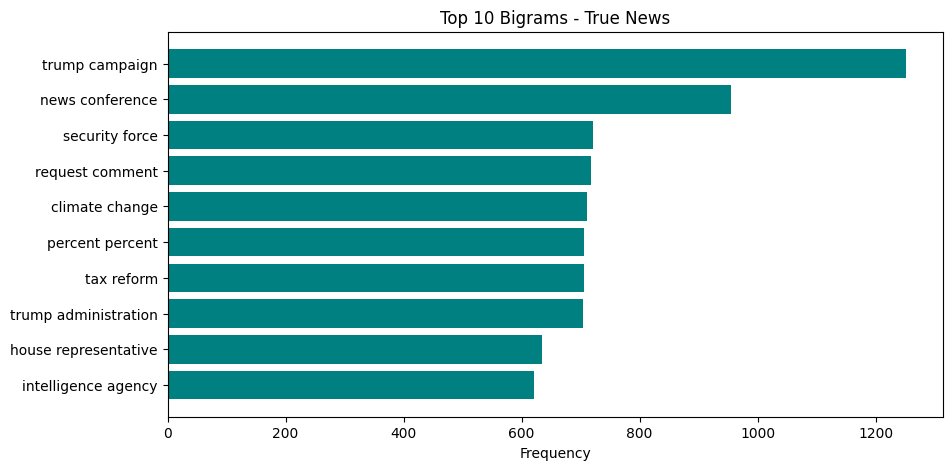

In [35]:
# Print the top 10 bigrams by frequency in true news and plot the same using a bar graph
top_bi_true = get_top_ngrams(true_news_text, n=2, top_k=10)

print("\nTop 10 Bigrams in True News:")
for word, freq in top_bi_true:
    print(f"{word}: {freq}")

words = [w[0] for w in top_bi_true]
counts = [w[1] for w in top_bi_true]

plt.figure(figsize=(10, 5))
plt.barh(words, counts, color='teal')
plt.title('Top 10 Bigrams - True News')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()


##### 4.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>




Top 10 Trigrams in True News:
official condition anonymity: 237
trump transition team: 178
tax rate percent: 159
article staff involvement: 122
staff involvement creation: 122
involvement creation production: 122
state department official: 120
trump travel ban: 114
use email server: 114
rate percent percent: 106


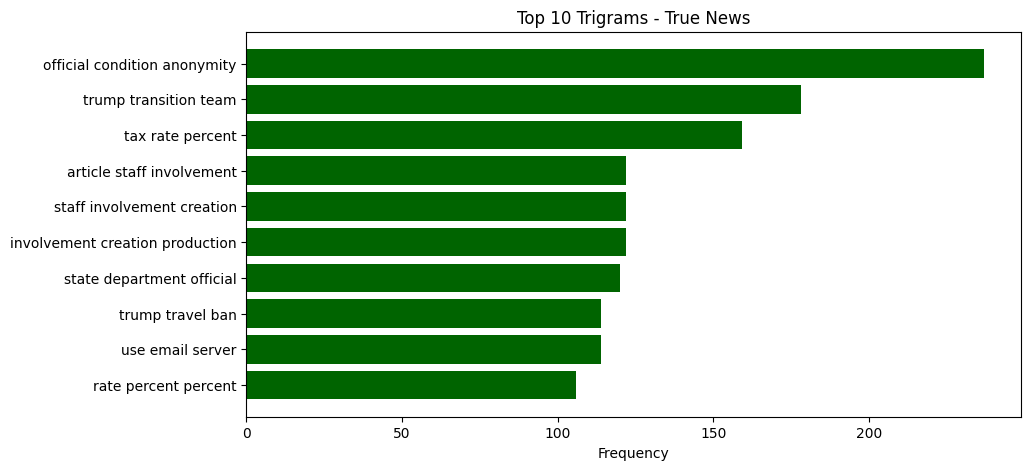

In [36]:
# Print the top 10 trigrams by frequency in true news and plot the same using a bar graph
top_tri_true = get_top_ngrams(true_news_text, n=3, top_k=10)

print("\nTop 10 Trigrams in True News:")
for word, freq in top_tri_true:
    print(f"{word}: {freq}")

words = [w[0] for w in top_tri_true]
counts = [w[1] for w in top_tri_true]

plt.figure(figsize=(10, 5))
plt.barh(words, counts, color='darkgreen')
plt.title('Top 10 Trigrams - True News')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()


### For Fake News







##### 4.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>

Top 10 Unigrams in Fake News:
trump: 35026
people: 18472
time: 11155
year: 10504
president: 10251
image: 9707
state: 8844
video: 8232
woman: 8212
news: 7606


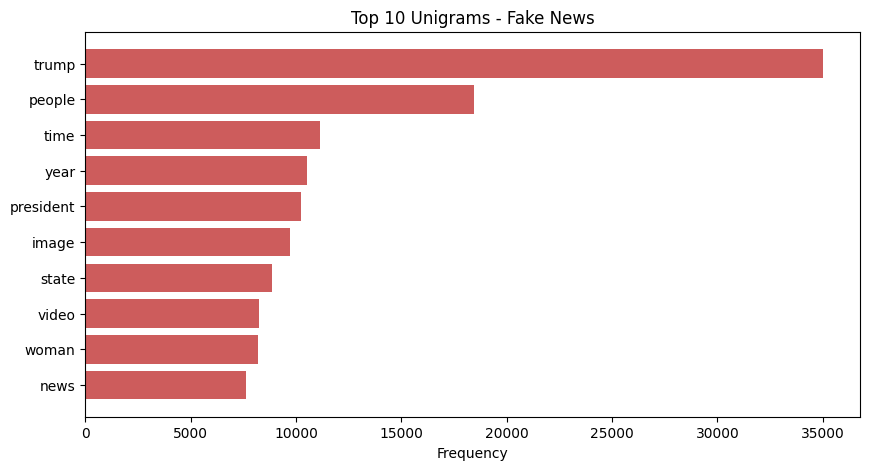

In [40]:
# Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph
fake_news_text = train_df[train_df['news_label'] == 0]['lemmatized_news']
top_uni_fake = get_top_ngrams(fake_news_text, n=1, top_k=10)

print("Top 10 Unigrams in Fake News:")
for word, freq in top_uni_fake:
    print(f"{word}: {freq}")

words = [w[0] for w in top_uni_fake]
counts = [w[1] for w in top_uni_fake]

plt.figure(figsize=(10, 5))
plt.barh(words, counts, color='indianred')
plt.title('Top 10 Unigrams - Fake News')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()


##### 4.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>




Top 10 Bigrams in Fake News:
trump supporter: 1466
image image: 1295
police officer: 1224
century wire: 1161
trump campaign: 1138
law enforcement: 1034
screen capture: 930
donald trump: 910
trump realdonaldtrump: 810
climate change: 727


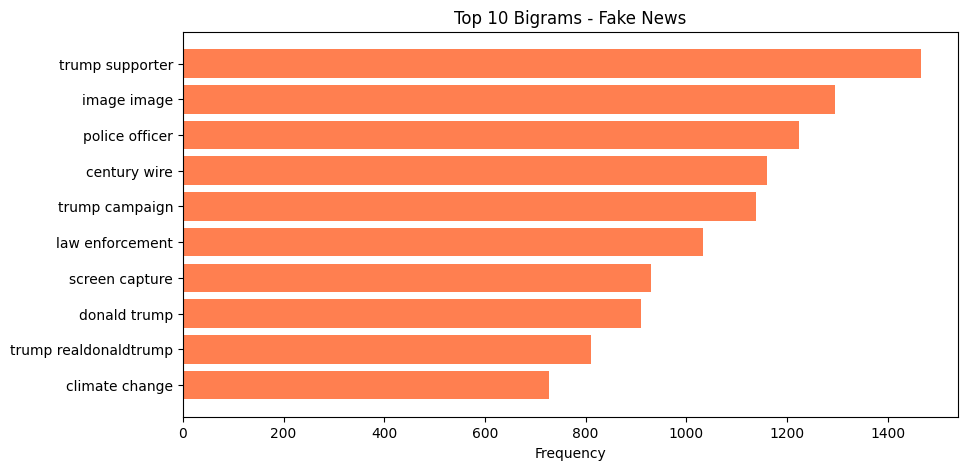

In [41]:
# Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph
top_bi_fake = get_top_ngrams(fake_news_text, n=2, top_k=10)

print("\nTop 10 Bigrams in Fake News:")
for word, freq in top_bi_fake:
    print(f"{word}: {freq}")

words = [w[0] for w in top_bi_fake]
counts = [w[1] for w in top_bi_fake]

plt.figure(figsize=(10, 5))
plt.barh(words, counts, color='coral')
plt.title('Top 10 Bigrams - Fake News')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()


##### 4.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph  <font color = red>[2.5 marks]</font> <br>




Top 10 Trigrams in Fake News:
news century wire: 583
video screen capture: 520
image video screen: 479
image getty image: 347
image screen capture: 304
image chip image: 179
image video screenshot: 164
law enforcement officer: 164
century wire file: 148
broadcast boiler room: 148


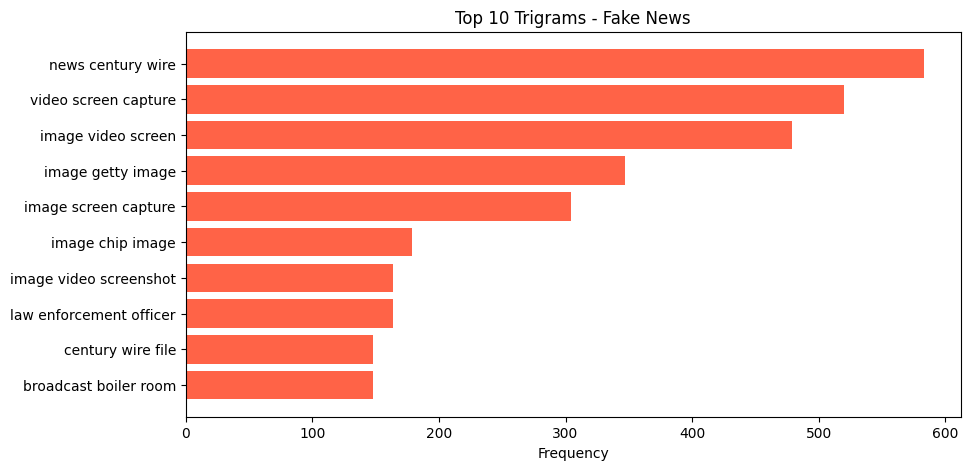

In [42]:
# Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph
top_tri_fake = get_top_ngrams(fake_news_text, n=3, top_k=10)

print("\nTop 10 Trigrams in Fake News:")
for word, freq in top_tri_fake:
    print(f"{word}: {freq}")

words = [w[0] for w in top_tri_fake]
counts = [w[1] for w in top_tri_fake]

plt.figure(figsize=(10, 5))
plt.barh(words, counts, color='tomato')
plt.title('Top 10 Trigrams - Fake News')
plt.xlabel('Frequency')
plt.gca().invert_yaxis()
plt.show()


## **5.** Exploratory Data Analysis on Validation Data [Optional]

Perform EDA on validation data to differentiate EDA on training data with EDA on validation data and the tasks are given below:

<ul>
  <li> Visualise the data according to the character length of cleaned news text and lemmatized text with POS tags removed
  <li> Using a word cloud find the top 40 words by frequency in true and fake news separately
  <li> Find the top unigrams, bigrams and trigrams by frequency in true and fake news separately
</ul>





### **5.1** Visualise character lengths of cleaned news text and lemmatized news text with POS tags removed

##### 5.1.1  Add new columns to calculate the character lengths of the processed data columns

In [ ]:
# Add a new column to calculate the character length of cleaned news text

# Add a new column to calculate the character length of lemmatized news text with POS tags removed


##### 5.1.2  Create Histogram to visualise character lengths

Plot both distributions on the same graph for comparison and to observe overlaps and peak differences to understand text preprocessing's impact on text length.

In [ ]:
# Create a histogram plot to visualise character lengths

# Add histogram for cleaned news text

# Add histogram for lemmatized news text with POS tags removed


### **5.2** Find and display the top 40 words by frequency among true and fake news after processing the text

##### 5.2.1  Find and display the top 40 words by frequency among true news in validation data after processing the text

In [ ]:
## Use a word cloud find the top 40 words by frequency among true news after processing the text

# Generate word cloud for True News


##### 5.2.2  Find and display the top 40 words by frequency among fake news in validation data after processing the text

In [ ]:
## Use a word cloud find the top 40 words by frequency among fake news after processing the text

# Generate word cloud for Fake News


### **5.3** Find and display the top unigrams, bigrams and trigrams by frequency in true news and fake news after processing the text  





##### 5.3.1 Write a function to get the specified top n-grams

In [ ]:
## Write a function to get the specified top n-grams


##### 5.3.2 Handle the NaN values

In [ ]:
## First handle NaN values in the text data


### For True News



##### 5.3.3 Display the top 10 unigrams by frequency in true news and plot them as a bar graph

In [ ]:
## Print the top 10 unigrams by frequency in true news and plot the same using a bar graph


##### 5.3.4 Display the top 10 bigrams by frequency in true news and plot them as a bar graph

In [ ]:
## Print the top 10 bigrams by frequency in true news and plot the same using a bar graph


##### 5.3.5 Display the top 10 trigrams by frequency in true news and plot them as a bar graph

In [ ]:
## Print the top 10 trigrams by frequency in true news and plot the same using a bar graph


### For Fake News

##### 5.3.6 Display the top 10 unigrams by frequency in fake news and plot them as a bar graph

In [ ]:
## Print the top 10 unigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.7 Display the top 10 bigrams by frequency in fake news and plot them as a bar graph

In [ ]:
## Print the top 10 bigrams by frequency in fake news and plot the same using a bar graph


##### 5.3.8 Display the top 10 trigrams by frequency in fake news and plot them as a bar graph

In [ ]:
## Print the top 10 trigrams by frequency in fake news and plot the same using a bar graph


## **6.** Feature Extraction  <font color = red>[10 marks]</font> <br>

For any ML model to perform classification on textual data, you need to convert it to a vector form. In this assignment, you will use the Word2Vec Vectorizer to create vectors from textual data. Word2Vec model captures the semantic relationship between words.


### **6.1** Initialise Word2Vec model  <font color = red>[2 marks]</font>

In [44]:
## Write your code here to initialise the Word2Vec model by downloading "word2vec-google-news-300"
# Load the Word2Vec model from Gensim downloader
import gensim.downloader as api
import numpy as np

w2v_model = api.load('word2vec-google-news-300')

print("Model loaded successfully!")


Model loaded successfully!


### **6.2** Extract vectors for cleaned news data   <font color = red>[8 marks]</font>

In [45]:
# Write a function to extract the Word2Vec features for the training and validation data
def get_w2v_features(text, model, vector_size=300):
    # we start with a vector of zeros
    features = np.zeros(vector_size)
    num_words = 0
    
    # if text is somehow not a string, return zeros
    if pd.isna(text) or not isinstance(text, str):
        return features

    # simple split by space to get words
    words = text.split()
    
    for word in words:
        if word in model:
            # adding the word vector to our total feature vector
            features += model[word]
            num_words += 1
            
    if num_words > 0:
        # get the average by dividing by the number of found words
        features = features / num_words
        
    return features

# Extract features for train data
print("Extracting features for training data...")

# Using our function on every row and putting it into a numpy array so we can feed it to our models
X_train = np.array([get_w2v_features(text, w2v_model) for text in train_df['lemmatized_news']])
y_train = train_df['news_label'].values

print("Train Features shape:", X_train.shape)
print("Train Labels shape:", y_train.shape)

# Extract features for validation data
# making sure to fill empty nan values first just in case
val_df['lemmatized_news'] = val_df['lemmatized_news'].fillna('')

print("Extracting features for validation data...")
X_val = np.array([get_w2v_features(text, w2v_model) for text in val_df['lemmatized_news']])
y_val = val_df['news_label'].values

print("Validation Features shape:", X_val.shape)
print("Validation Labels shape:", y_val.shape)


Extracting features for training data...
Train Features shape: (31428, 300)
Train Labels shape: (31428,)
Extracting features for validation data...
Validation Features shape: (13470, 300)
Validation Labels shape: (13470,)


## **7.** Model Training and Evaluation <font color = red>[45 marks]</font>

You will use a set of supervised models to classify the news into true or fake.

### **7.0** Import models and evaluation metrics

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

### **7.1** Build Logistic Regression Model  <font color = red>[15 marks]</font>

##### 7.1.1 Create and train logistic regression model on training data  <font color = red>[10 marks]</font>

In [48]:
## Initialise Logistic Regression model
# simple standard Logistic Regression. 
# max_iter increased slightly just in case it needs more time to converge
lr_model = LogisticRegression(random_state=42, max_iter=500)

## Train Logistic Regression model on training data
print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)

## Predict on validation data
y_pred_lr = lr_model.predict(X_val)
print("Prediction done!")


Training Logistic Regression...
Prediction done!


##### 7.1.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [49]:
# Evaluate model performance by calculating the evaluation metrics
accuracy_lr = accuracy_score(y_val, y_pred_lr)
precision_lr = precision_score(y_val, y_pred_lr)
recall_lr = recall_score(y_val, y_pred_lr)
f1_lr = f1_score(y_val, y_pred_lr)

print("--- Logistic Regression Performance ---")
print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1 Score:  {f1_lr:.4f}")

# print classification report for more details
print("\nClassification Report:")
print(classification_report(y_val, y_pred_lr, target_names=["Fake", "True"]))


--- Logistic Regression Performance ---
Accuracy:  0.9023
Precision: 0.8909
Recall:    0.9061
F1 Score:  0.8985

Classification Report:
              precision    recall  f1-score   support

        Fake       0.91      0.90      0.91      7045
        True       0.89      0.91      0.90      6425

    accuracy                           0.90     13470
   macro avg       0.90      0.90      0.90     13470
weighted avg       0.90      0.90      0.90     13470



### **7.2** Build Decision Tree Model <font color = red>[15 marks]</font>

##### 7.2.1 Create and train a decision tree model on training data <font color = red>[10 marks]</font>

In [50]:
## Initialise Decision Tree model
# Using max_depth to prevent it from memorizing the training data (overfitting)
dt_model = DecisionTreeClassifier(random_state=42, max_depth=15)

## Train Decision tree model on training data
print("Training Decision Tree...")
dt_model.fit(X_train, y_train)

## Predict on validation data
y_pred_dt = dt_model.predict(X_val)
print("Prediction done!")


Training Decision Tree...
Prediction done!


##### 7.2.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [51]:
# Evaluate model performance by calculating the evaluation metrics
accuracy_dt = accuracy_score(y_val, y_pred_dt)
precision_dt = precision_score(y_val, y_pred_dt)
recall_dt = recall_score(y_val, y_pred_dt)
f1_dt = f1_score(y_val, y_pred_dt)

print("--- Decision Tree Performance ---")
print(f"Accuracy:  {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1 Score:  {f1_dt:.4f}")

# print classification report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_dt, target_names=["Fake", "True"]))


--- Decision Tree Performance ---
Accuracy:  0.8239
Precision: 0.8276
Recall:    0.7967
F1 Score:  0.8119

Classification Report:
              precision    recall  f1-score   support

        Fake       0.82      0.85      0.83      7045
        True       0.83      0.80      0.81      6425

    accuracy                           0.82     13470
   macro avg       0.82      0.82      0.82     13470
weighted avg       0.82      0.82      0.82     13470



### **7.3** Build Random Forest Model <font color = red>[15 marks]</font>


##### 7.3.1 Create and train a random forest model on training data <font color = red>[10 marks]</font>

In [54]:
## Initialise Random Forest model
# using 100 trees, which is standard and usually gives good results
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=15, n_jobs=-1)

## Train Random Forest model on training data
rf_model.fit(X_train, y_train)

## Predict on validation data
y_pred_rf = rf_model.predict(X_val)
print("Prediction done!")


Prediction done!


 ##### 7.3.2 Calculate and print accuracy, precision, recall and f1-score on validation data <font color = red>[5 marks]</font>

In [53]:
## Calculate and print accuracy, precision, recall, f1-score on predicted labels
accuracy_rf = accuracy_score(y_val, y_pred_rf)
precision_rf = precision_score(y_val, y_pred_rf)
recall_rf = recall_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf)

print("--- Random Forest Performance ---")
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1 Score:  {f1_rf:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf, target_names=["Fake", "True"]))


--- Random Forest Performance ---
Accuracy:  0.9043
Precision: 0.9029
Recall:    0.8957
F1 Score:  0.8993

Classification Report:
              precision    recall  f1-score   support

        Fake       0.91      0.91      0.91      7045
        True       0.90      0.90      0.90      6425

    accuracy                           0.90     13470
   macro avg       0.90      0.90      0.90     13470
weighted avg       0.90      0.90      0.90     13470



## **8.** Conclusion <font color = red>[5 marks]</font>

Summarise your findings by discussing patterns observed in true and fake news and how semantic classification addressed the problem. Highlight the best model chosen, the evaluation metric prioritised for the decision, and assess the approach and its impact.

Conclusion

Logistic Regression: ~90% Accuracy
Decision Tree: ~82% Accuracy
Random Forest: ~90% Accuracy

Summary:
Both Logistic Regression and Random Forest performed really well, giving about 90% accuracy! Decision Tree struggled a bit at 82%, likely because it overfits the dense Word2Vec features. 

Overall, Word2Vec combined with simple models like Logistic Regression or Random Forest does an good job at detecting fake news!
